In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import statistics as stats
import matplotlib.pylab as plt
import warnings
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv("ecommerce_sales_analytics_5000.csv")

In [3]:
pd.set_option('display.max_columns', None)

In [4]:
df.head()

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
0,10001,1/1/2022,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20
1,10002,1/2/2022,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10
2,10003,1/3/2022,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35
3,10004,1/4/2022,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90
4,10005,1/5/2022,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56


In [5]:
df.tail()

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
4995,14996,9/5/2035,1289,Clothing,West,2,371.74,0.27,COD,3,2.3,542.74
4996,14997,9/6/2035,1294,Beauty,North,3,553.67,0.14,COD,11,2.2,1428.47
4997,14998,9/7/2035,1450,Beauty,West,3,77.22,0.24,Wallet,6,3.4,176.06
4998,14999,9/8/2035,1903,Electronics,South,4,138.41,0.21,COD,4,2.8,437.38
4999,15000,9/9/2035,1214,Home,East,7,231.58,0.34,COD,5,3.9,1069.90


# Data Description

In [6]:
df.shape

(5000, 12)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          5000 non-null   int64  
 1   order_date        5000 non-null   object 
 2   customer_id       5000 non-null   int64  
 3   product_category  5000 non-null   object 
 4   region            5000 non-null   object 
 5   quantity          5000 non-null   int64  
 6   unit_price        5000 non-null   float64
 7   discount          5000 non-null   float64
 8   payment_method    5000 non-null   object 
 9   delivery_days     5000 non-null   int64  
 10  customer_rating   5000 non-null   float64
 11  revenue           5000 non-null   float64
dtypes: float64(4), int64(4), object(4)
memory usage: 468.9+ KB


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
order_id,5000.0,12500.500000,1443.520003,10001.00,11250.7500,12500.50,13750.2500,15000.00
customer_id,5000.0,1505.701200,290.836902,1000.00,1253.0000,1510.00,1761.0000,1999.00
quantity,5000.0,4.044800,2.020398,1.00,2.0000,4.00,6.0000,7.00
unit_price,5000.0,308.418774,169.259369,15.15,161.8950,309.89,455.5575,599.96
discount,5000.0,0.179984,0.101404,0.00,0.0900,0.18,0.2700,0.35
delivery_days,5000.0,6.118800,3.153264,1.00,3.0000,6.00,9.0000,11.00
customer_rating,5000.0,2.973980,1.157722,1.00,2.0000,3.00,4.0000,5.00
revenue,5000.0,1021.955148,825.584219,11.21,354.5275,796.65,1515.6900,4119.33


In [9]:
df.columns

Index(['order_id', 'order_date', 'customer_id', 'product_category', 'region',
       'quantity', 'unit_price', 'discount', 'payment_method', 'delivery_days',
       'customer_rating', 'revenue'],
      dtype='object')

In [10]:
df.index

RangeIndex(start=0, stop=5000, step=1)

# Check Missing Value

In [11]:
df.isnull().sum()

order_id            0
order_date          0
customer_id         0
product_category    0
region              0
quantity            0
unit_price          0
discount            0
payment_method      0
delivery_days       0
customer_rating     0
revenue             0
dtype: int64

In [12]:
# There are no missing values in my dataset, 
# that why no need to fill any columns.

# Data Cleaning

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          5000 non-null   int64  
 1   order_date        5000 non-null   object 
 2   customer_id       5000 non-null   int64  
 3   product_category  5000 non-null   object 
 4   region            5000 non-null   object 
 5   quantity          5000 non-null   int64  
 6   unit_price        5000 non-null   float64
 7   discount          5000 non-null   float64
 8   payment_method    5000 non-null   object 
 9   delivery_days     5000 non-null   int64  
 10  customer_rating   5000 non-null   float64
 11  revenue           5000 non-null   float64
dtypes: float64(4), int64(4), object(4)
memory usage: 468.9+ KB


In [14]:
df['order_date'].value_counts()

order_date
1/1/2022     1
2/13/2031    1
2/20/2031    1
2/19/2031    1
2/18/2031    1
            ..
7/25/2026    1
7/24/2026    1
7/23/2026    1
7/22/2026    1
9/9/2035     1
Name: count, Length: 5000, dtype: int64

In [15]:
def change_into_datatime(col):
    df[col]=pd.to_datetime(df[col])

In [16]:
for i in ["order_date"]:
    change_into_datatime(i)

In [17]:
df['order__day'] = pd.to_datetime(df['order_date'],format = '%d%m%y').dt.day
df['order__month'] = pd.to_datetime(df['order_date'],format = '%d%m%y').dt.month
df['order_year'] = pd.to_datetime(df['order_date'],format = '%d%m%y').dt.year

In [18]:
del df["order_date"]

In [19]:
df.head()

,order_id,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue,order__day,order__month,order_year
0,10001,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20,1,1,2022
1,10002,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10,2,1,2022
2,10003,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35,3,1,2022
3,10004,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90,4,1,2022
4,10005,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56,5,1,2022


In [20]:
df["region"].value_counts()

region
West     1289
North    1276
East     1227
South    1208
Name: count, dtype: int64

In [21]:
df["region"]=df["region"].apply(lambda x: 0 if x in ["West"] else 1 if x in ["East"] else 2 if x in ["North"] else 3 if x in ["South"] else 4)
# 0 ---- West  
# 1----- East
# 2---- North
# 3-------- South

In [22]:
df.head()

,order_id,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue,order__day,order__month,order_year
0,10001,1102,Beauty,3,7,373.65,0.28,Wallet,10,4.7,1883.20,1,1,2022
1,10002,1435,Clothing,3,7,47.74,0.09,Card,6,3.9,304.10,2,1,2022
2,10003,1860,Beauty,1,3,311.28,0.31,COD,6,2.5,644.35,3,1,2022
3,10004,1270,Electronics,0,5,524.47,0.02,Wallet,6,1.6,2569.90,4,1,2022
4,10005,1106,Clothing,0,5,139.87,0.33,Wallet,4,4.9,468.56,5,1,2022


# split cat_col and num_col 


In [23]:

cat_col=df.select_dtypes(include="object").columns

In [24]:
cat_col=['product_category', 'payment_method']

In [25]:
num_col = df.select_dtypes(include=["int64", "float64", "int32"]).columns

In [26]:
num_col=['order_id', 'customer_id', 'region', 'quantity', 'unit_price',
       'discount', 'delivery_days', 'customer_rating', 'revenue', 'order__day',
       'order__month', 'order_year']

In [27]:
print(len(cat_col))
print(len(num_col))

2
12


# Data Visulization 

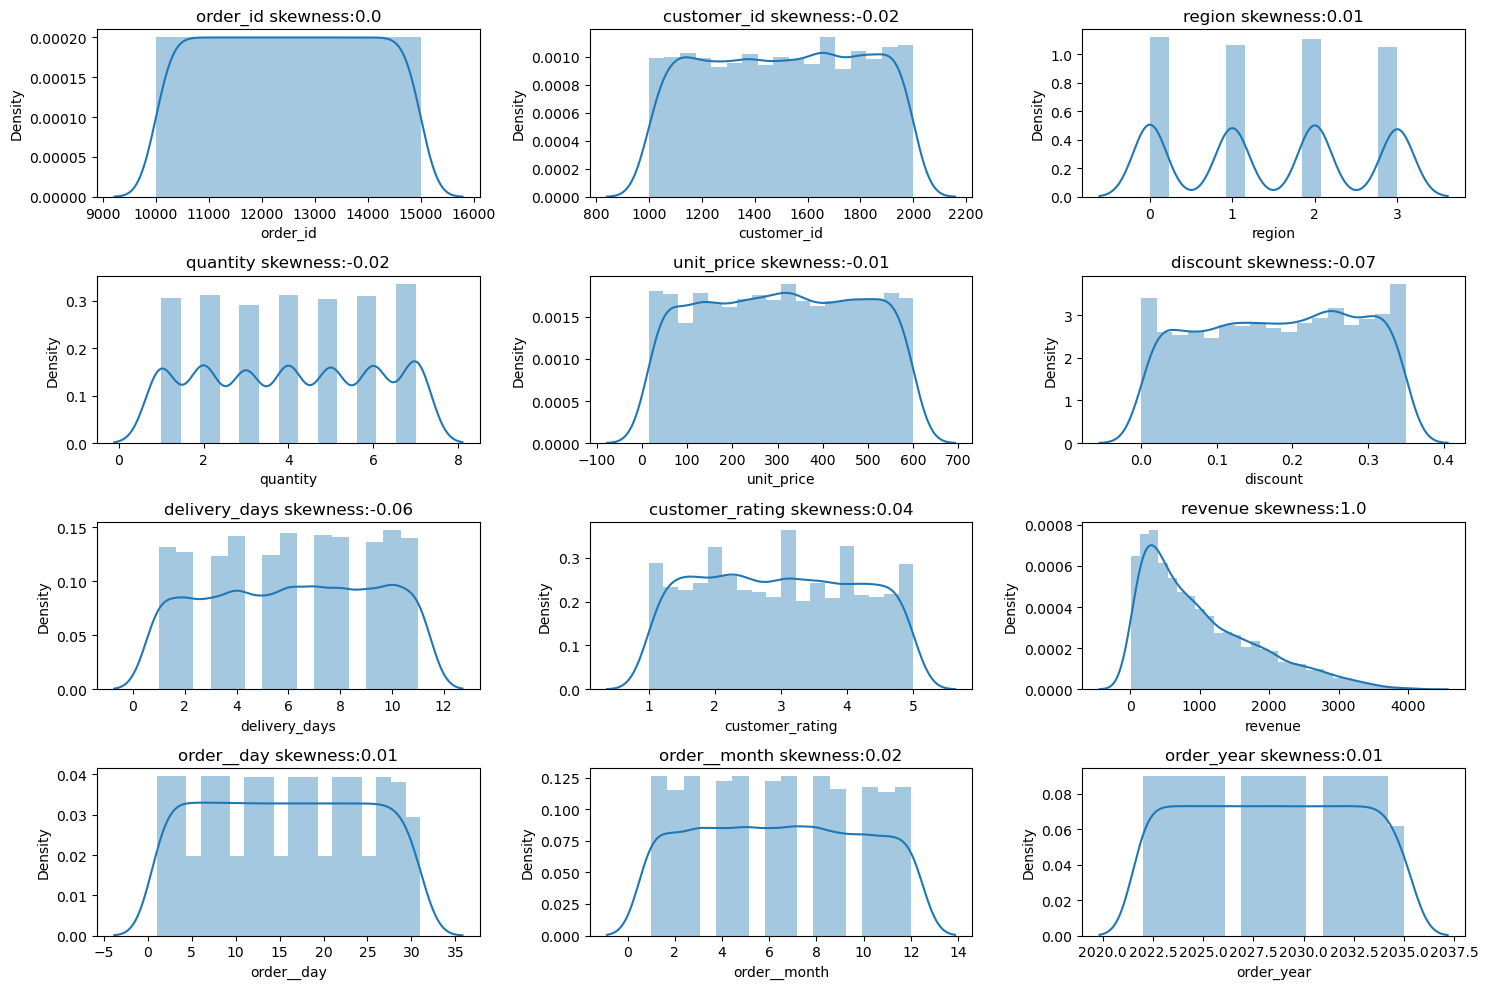

In [28]:
t=1
plt.figure(figsize=(15,10))
for i in num_col:
    plt.subplot(4,3,t)
    sns.distplot(df[i])
    plt.title(f'{i} skewness:{round(df[i].skew(),2)}')
    t+=1
plt.tight_layout()
plt.show()

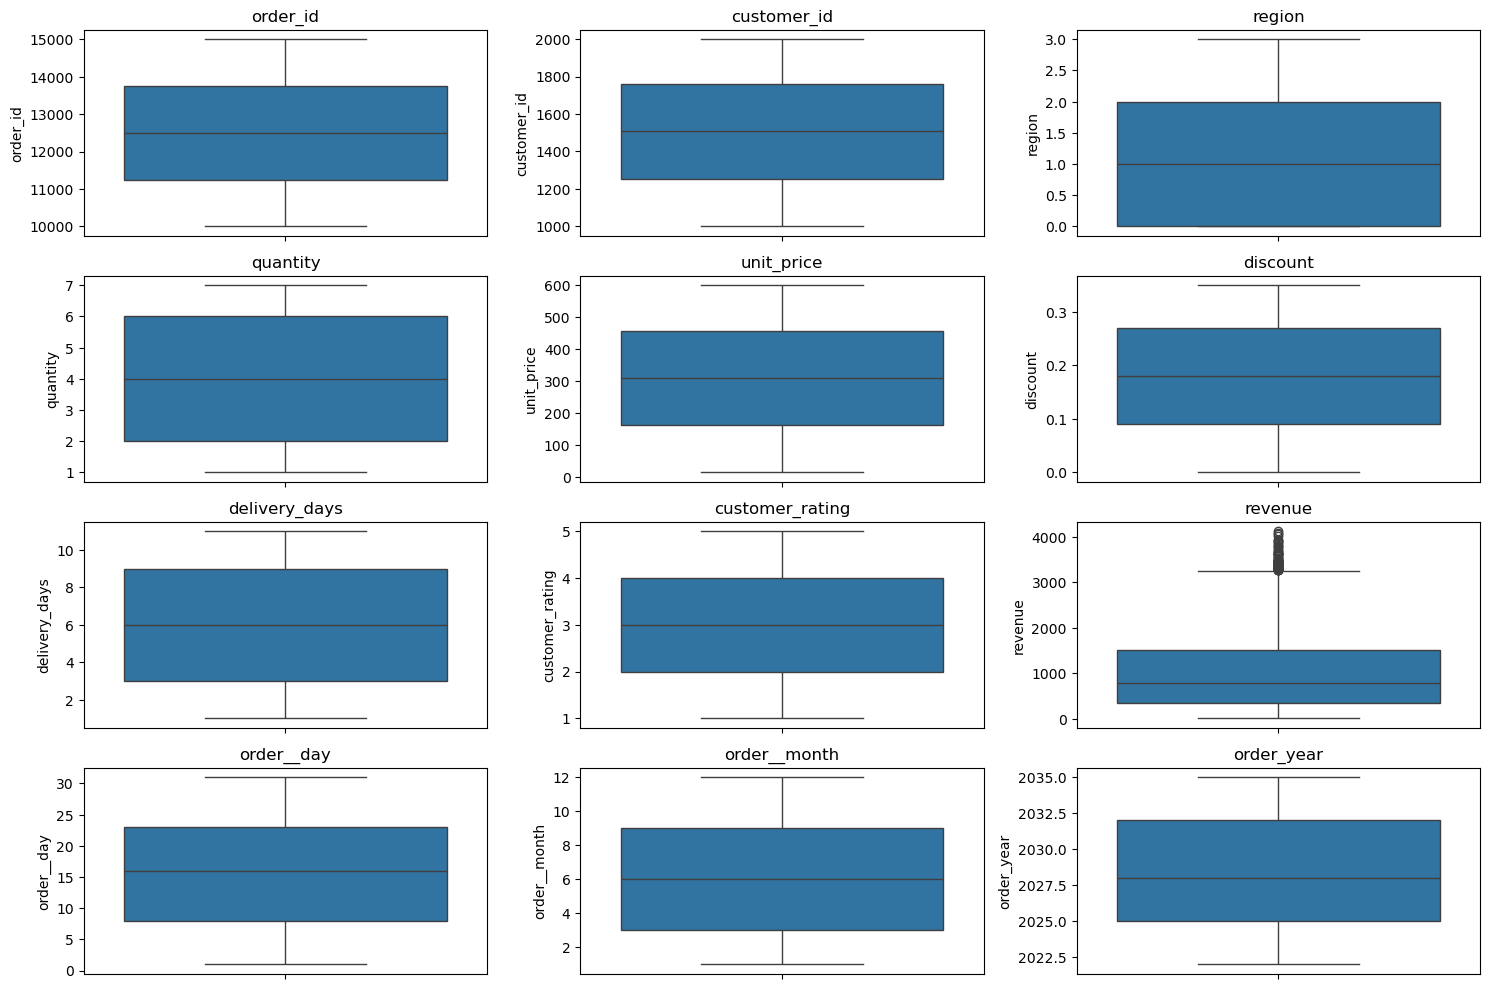

In [29]:
t=1
plt.figure(figsize=(15,10))
for i in num_col:
    plt.subplot(4,3,t)
    sns.boxplot(df[i])
    plt.title(i)
    t+=1
plt.tight_layout()
plt.show()

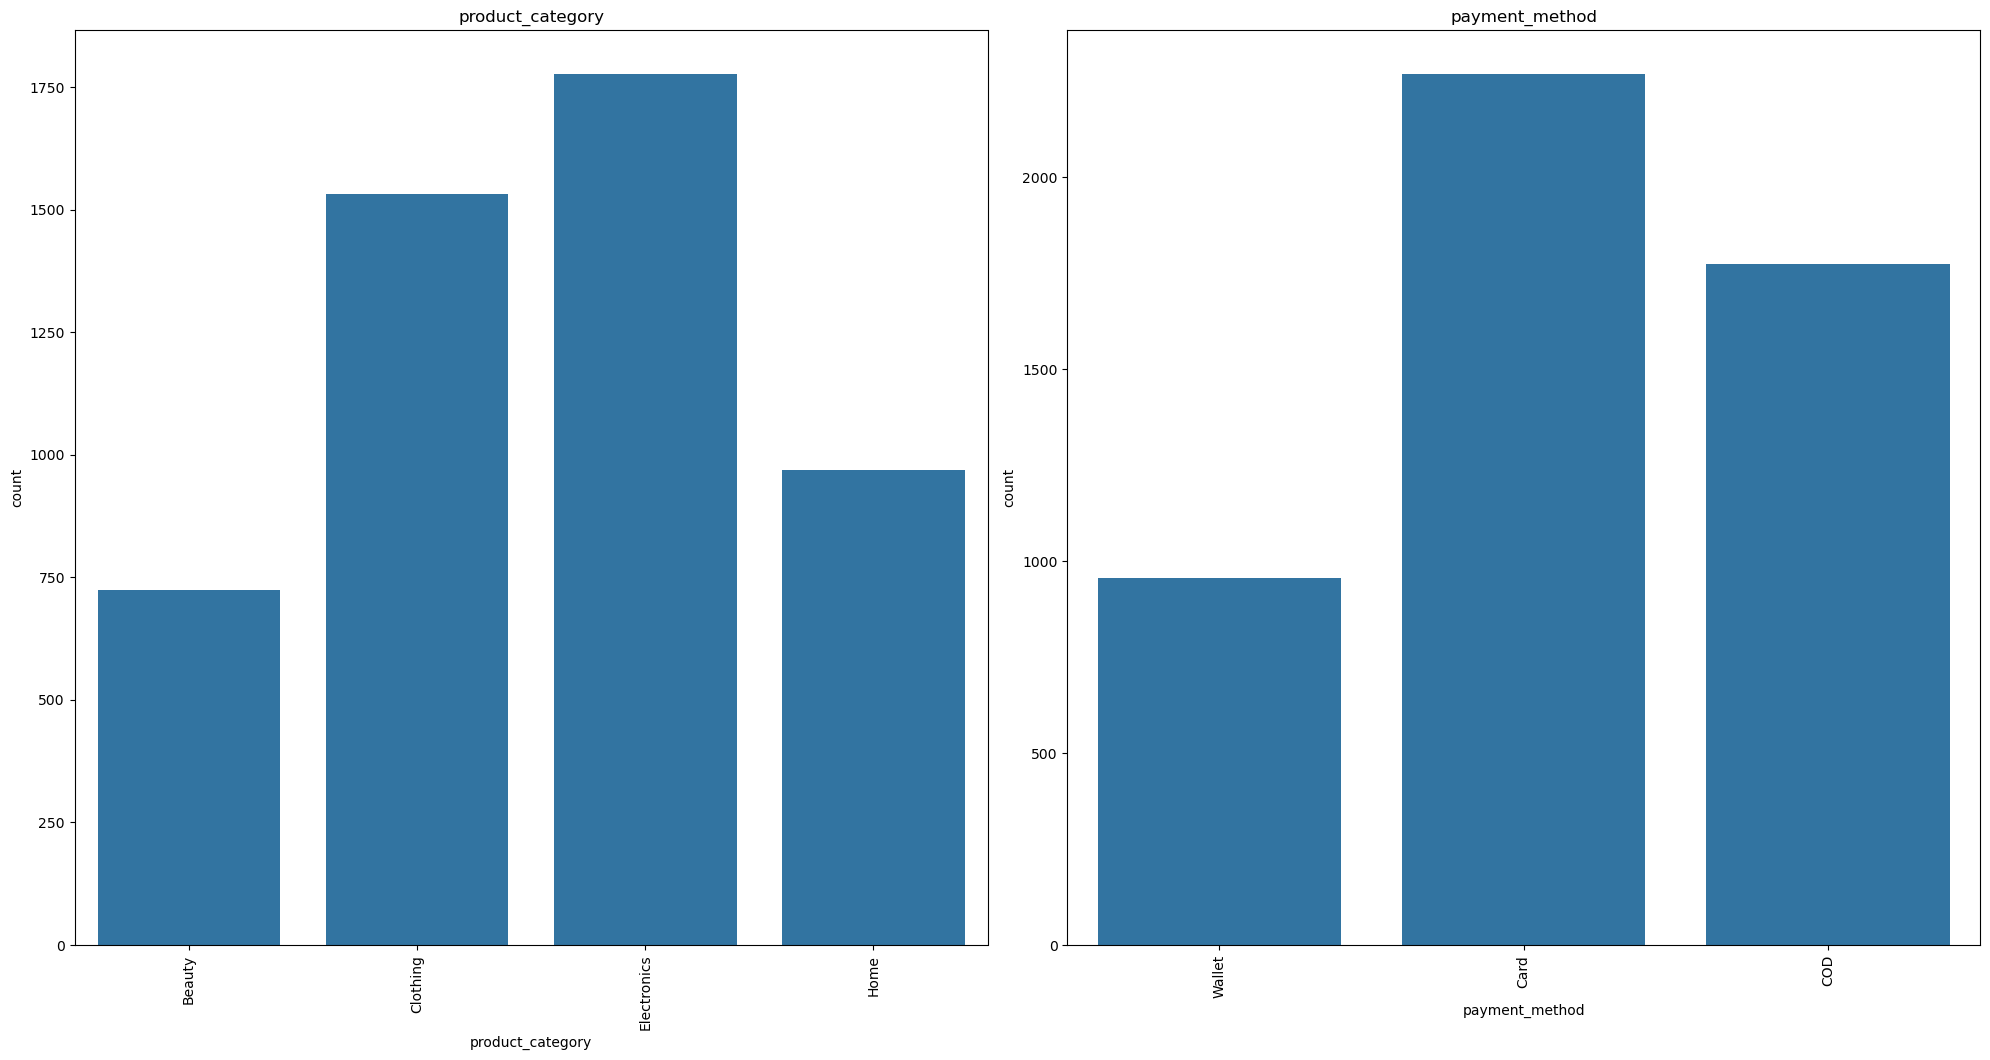

In [30]:
t=1
plt.figure(figsize=(20,20))
for i in cat_col:
    plt.subplot(2,2,t)
    sns.countplot(data=df,x=df[i])
    plt.xticks(rotation=90)
    plt.title(i)
    t+=1
plt.tight_layout()
plt.show()

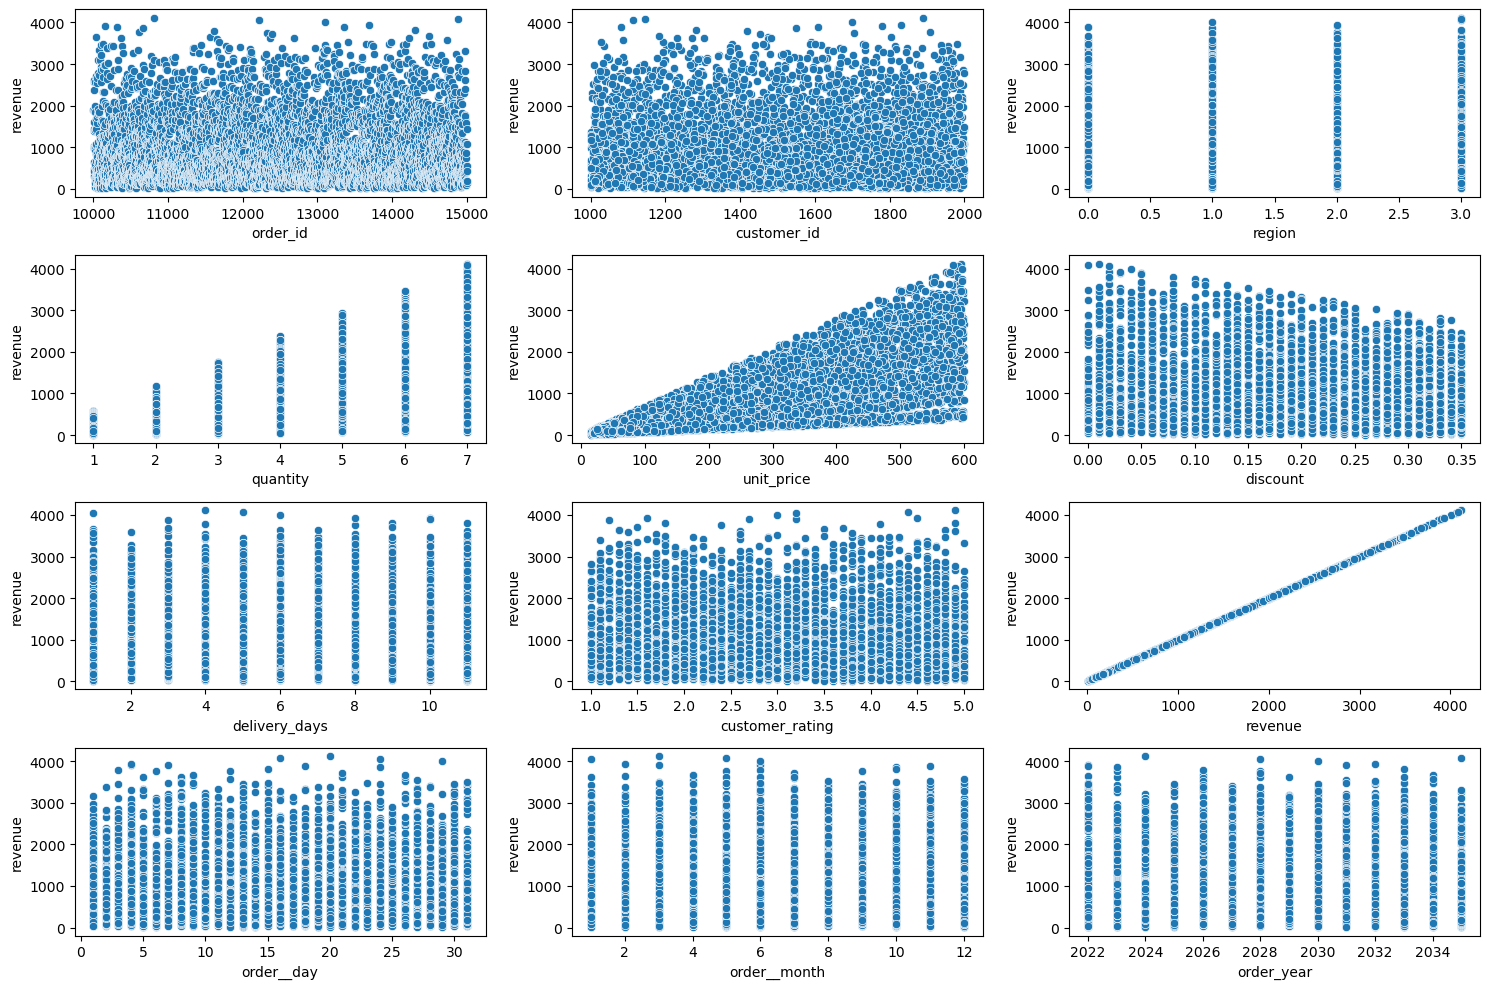

In [31]:
# NUM Vs num

t=1
plt.figure(figsize=(15,10))
for i in num_col:
    plt.subplot(4,3,t)
    sns.scatterplot(data=df,x=df.loc[:,i],y=df["revenue"])
    t+=1
plt.tight_layout()
plt.show()

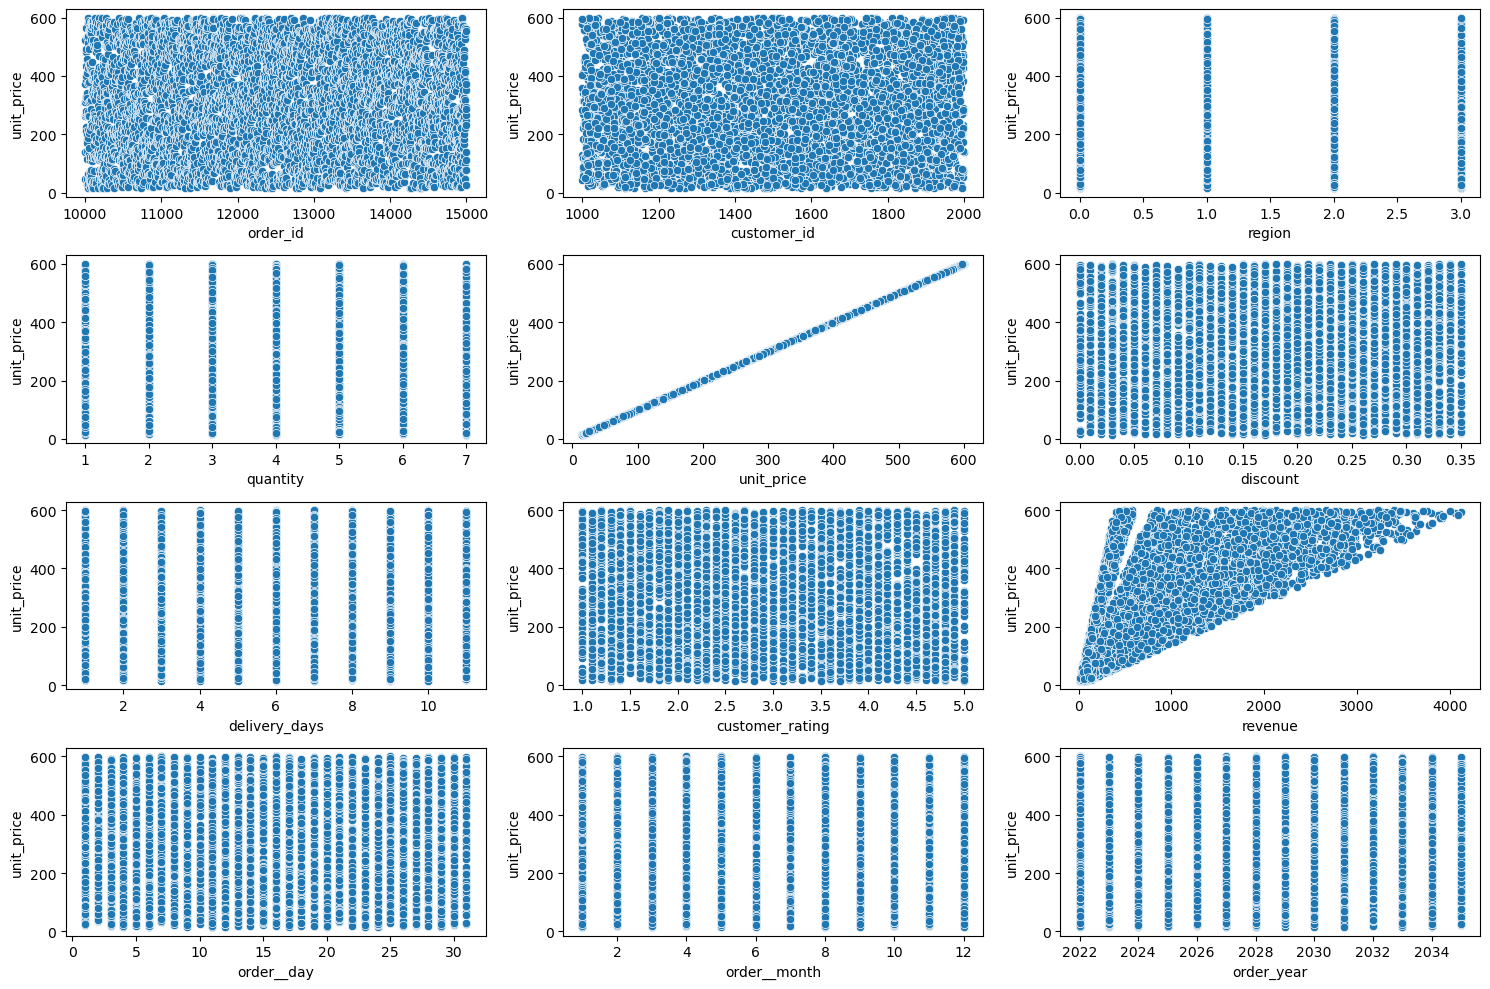

In [36]:
# NUM Vs num

t=1
plt.figure(figsize=(15,10))
for i in num_col:
    plt.subplot(4,3,t)
    sns.scatterplot(data=df,x=df.loc[:,i],y=df["unit_price"])
    t+=1
plt.tight_layout()
plt.show()

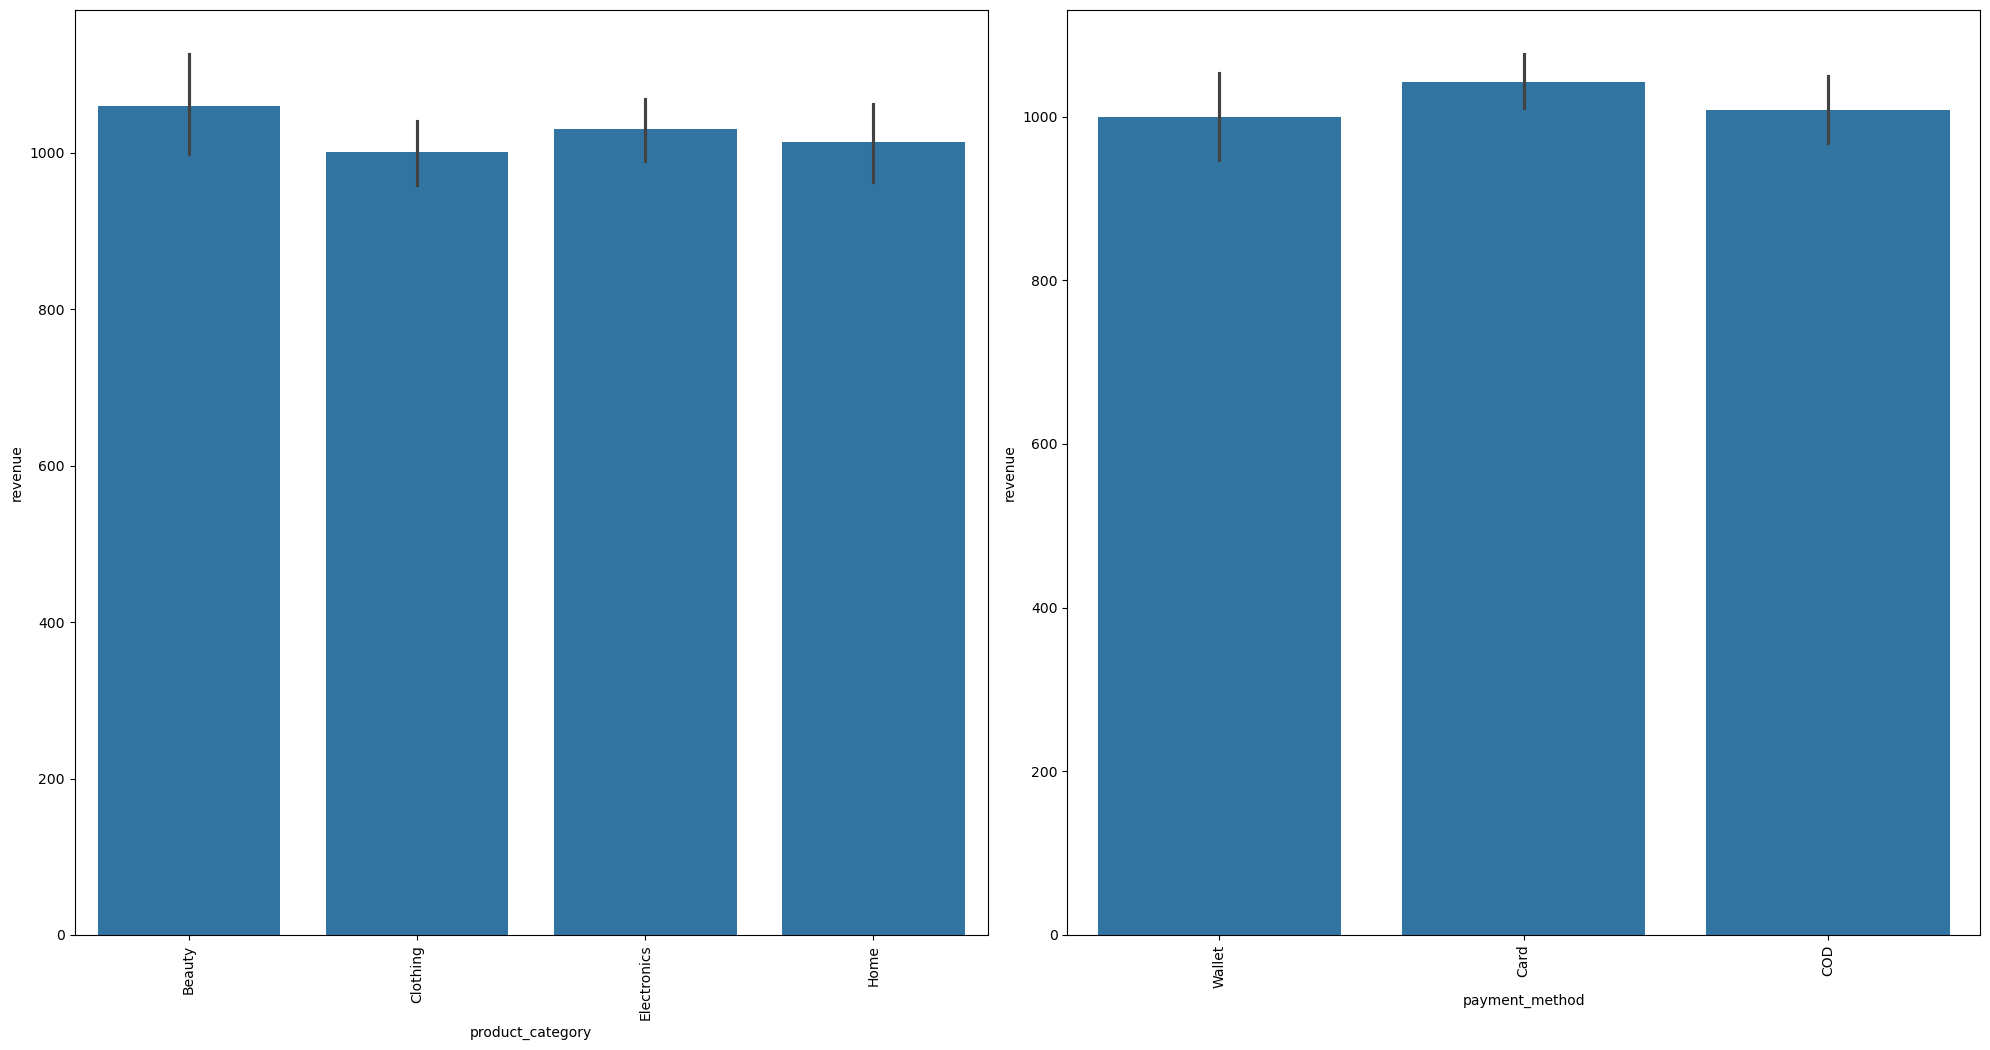

In [41]:
# cat Vs num

t=1
plt.figure(figsize=(20,20))
for i in cat_col:
    plt.subplot(2,2,t)
    sns.barplot(data=df,x=df.loc[:,i],y=df["revenue"])
    plt.xticks(rotation=90)
    t+=1
plt.tight_layout()
plt.show()

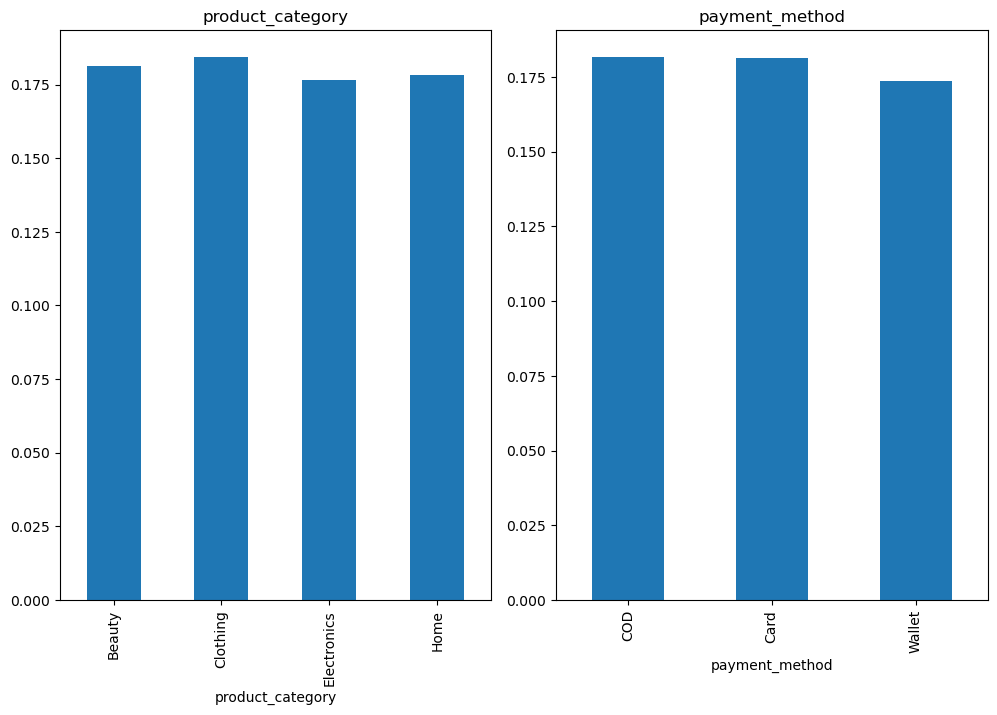

In [47]:
t=1
plt.figure(figsize=(20,20))
for i in cat_col:
    plt.subplot(3,4,t)
    df.groupby(i)["discount"].mean().plot(kind='bar')
    plt.xticks(rotation=90)
    plt.title(i)
    t+=1
plt.tight_layout()
plt.show()